# MLP baseline — real-response inverse (ADITYA-U)

**Diagnostic baseline.** Question it answers: does a plain MLP also collapse to the
mean like `PINN_Transformer_scaffold.ipynb` (val relative-L2 ~0.69, identical output
every sample), or does it learn the inverse?

Same synthetic data and same physics-informed loss as the scaffold. Only two things
differ:

- **Model**: a plain MLP (`6100 -> 1024 -> 512 -> 599`, Softplus head), no attention.
- **Input**: `log1p(counts)` then z-score standardized (train stats), *not*
  sum-normalized. HXR spectra span orders of magnitude; the scaffold's ~1e-4
  sum-normalized input gave the model almost no gradient signal.

### Result (this run's seed)

MLP reaches **val relative-L2 ~0.28** and is still improving at 40 epochs;
cross-sample prediction spread ~= signal amplitude (it is input-responsive, not
collapsed). Conclusion: the scaffold's failure was architecture + input
representation, **not** a physics ceiling — `H_d` carries recoverable information.

### Same caveats as the scaffold

`H` is detector-only `H_d`, so `x_pred` is a photon spectrum, not the runaway-electron
distribution `f`. Synthetic prior is a placeholder. Everything sum-normalized (units
unresolved). See `docs/open_physics_questions.md`, `docs/considerations.md`.

## 1. Config

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

CWD = Path.cwd()
REPO = CWD if (CWD / "src").is_dir() else CWD.parent
assert (REPO / "src" / "response_matrix.py").exists(), f"run from the repo root; got {CWD}"
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CFG = dict(
    n_train=600, n_val=150, total_counts=1.0e4,
    hidden=(1024, 512), dropout=0.1,
    epochs=40, batch_size=32, lr=1e-3,
    lambda_res=1.0, lambda_tv=1e-3,
)
torch.manual_seed(SEED); np.random.seed(SEED)
print("device:", DEVICE)

device: cpu


## 2. Real response matrix

In [2]:
from src.response_matrix import load_response_matrix

rm = load_response_matrix(REPO / "data" / "response_matrix.csv")
H_np = rm.h.astype(np.float32)
n_meas, n_true = H_np.shape
H = torch.from_numpy(H_np).to(DEVICE)
print(f"H {H_np.shape}  E_true {rm.e_true_keV[0]:.0f}..{rm.e_true_keV[-1]:.0f} keV")

H (6100, 599)  E_true 20..6000 keV


## 3. Synthetic data

Identical generator to the scaffold (`random_true_distribution`), so results are
directly comparable. `build_dataset` here returns **raw** Poisson counts; input
scaling is applied in the next cell.

In [3]:
from src.synthetic import simulate_counts


def random_true_distribution(e_true_keV: np.ndarray, rng: np.random.Generator) -> np.ndarray:
    e = np.asarray(e_true_keV, dtype=float)
    x = np.exp(-e / rng.uniform(150.0, 900.0))
    for _ in range(rng.integers(1, 4)):
        loc = rng.uniform(e.min(), e.max())
        width = rng.uniform(80.0, 500.0)
        amp = rng.uniform(0.2, 1.5)
        x += amp * np.exp(-((e - loc) ** 2) / (2.0 * width**2))
    if rng.random() < 0.5:
        p = rng.uniform(1.5, 3.5)
        x += 0.3 * (e.min() + 50.0) ** p / (e + 50.0) ** p
    x = np.clip(x, 0.0, None)
    return (x / x.sum()).astype(np.float32)


def build_dataset(n: int, seed: int):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, n_true), dtype=np.float32)
    Yraw = np.zeros((n, n_meas), dtype=np.float32)
    for i in range(n):
        x_true = random_true_distribution(rm.e_true_keV, rng)
        _, y_noisy = simulate_counts(H_np, x_true, CFG["total_counts"], seed=int(rng.integers(1 << 31)))
        X[i] = x_true
        Yraw[i] = y_noisy
    return torch.from_numpy(Yraw), torch.from_numpy(X)


Yraw_tr, X_tr = build_dataset(CFG["n_train"], SEED + 1)
Yraw_va, X_va = build_dataset(CFG["n_val"], SEED + 2)
print("train", tuple(Yraw_tr.shape), "val", tuple(Yraw_va.shape))

train (600, 6100) val (150, 6100)


## 4. Input scaling — the key change

`log1p` compresses the dynamic range; standardizing with **training** mean/std puts the
input in a range the network can actually use. A separate sum-normalized copy of the
measurement feeds the physics-residual term (same convention as the scaffold).

In [4]:
Yl_tr = torch.log1p(Yraw_tr)
mu = Yl_tr.mean(0, keepdim=True)
sd = Yl_tr.std(0, keepdim=True).clamp_min(1e-6)

Yin_tr = ((Yl_tr - mu) / sd).to(DEVICE)
Yin_va = ((torch.log1p(Yraw_va) - mu) / sd).to(DEVICE)

Yn_tr = (Yraw_tr / Yraw_tr.sum(1, keepdim=True).clamp_min(1e-12)).to(DEVICE)
Yn_va = (Yraw_va / Yraw_va.sum(1, keepdim=True).clamp_min(1e-12)).to(DEVICE)
X_tr_d, X_va_d = X_tr.to(DEVICE), X_va.to(DEVICE)

train_dl = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(Yin_tr, Yn_tr, X_tr_d), batch_size=CFG["batch_size"], shuffle=True
)

## 5. Model

In [5]:
class MLP(nn.Module):
    def __init__(self, n_in, n_out, hidden, dropout):
        super().__init__()
        dims = [n_in, *hidden]
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU(), nn.Dropout(dropout)]
        layers += [nn.Linear(dims[-1], n_out), nn.Softplus()]
        self.net = nn.Sequential(*layers)

    def forward(self, y):
        x = self.net(y)
        return x / x.sum(1, keepdim=True).clamp_min(1e-12)


model = MLP(n_meas, n_true, CFG["hidden"], CFG["dropout"]).to(DEVICE)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

params: 7,079,511


## 6. Loss (same as the scaffold)

In [6]:
def pinn_loss(x_pred, x_true, y_meas):
    sup = F.mse_loss(x_pred, x_true)
    y_sim = x_pred @ H.T
    y_sim = y_sim / y_sim.sum(dim=1, keepdim=True).clamp_min(1e-12)
    res = F.mse_loss(y_sim, y_meas)
    tv = (x_pred[:, 1:] - x_pred[:, :-1]).abs().mean()
    return sup + CFG["lambda_res"] * res + CFG["lambda_tv"] * tv, {"sup": sup.item(), "res": res.item()}


def rel_l2(a, b):
    return (torch.linalg.norm(a - b, dim=1) / torch.linalg.norm(b, dim=1).clamp_min(1e-12)).mean().item()

## 7. Train

In [7]:
opt = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
hist = {"train": [], "val": [], "val_l2": []}

for epoch in range(1, CFG["epochs"] + 1):
    model.train()
    running = 0.0
    for yb, ynb, xb in train_dl:
        opt.zero_grad()
        loss, _ = pinn_loss(model(yb), xb, ynb)
        loss.backward()
        opt.step()
        running += loss.item() * len(yb)
    tl = running / len(train_dl.dataset)

    model.eval()
    with torch.no_grad():
        xp = model(Yin_va)
        vloss, parts = pinn_loss(xp, X_va_d, Yn_va)
        vl2 = rel_l2(xp, X_va_d)
    hist["train"].append(tl); hist["val"].append(vloss.item()); hist["val_l2"].append(vl2)
    if epoch == 1 or epoch % 5 == 0:
        print(f"epoch {epoch:3d} | train {tl:.3e} | val {vloss.item():.3e} "
              f"(sup {parts['sup']:.2e} res {parts['res']:.2e}) | val relL2 {vl2:.4f}")

print("final val relative-L2 (shape):", round(hist['val_l2'][-1], 4), " (scaffold was ~0.69)")

epoch   1 | train 6.357e-06 | val 4.735e-06 (sup 3.99e-06 res 5.62e-07) | val relL2 0.6621
epoch   5 | train 2.066e-06 | val 2.569e-06 (sup 2.01e-06 res 4.17e-07) | val relL2 0.4283
epoch  10 | train 1.140e-06 | val 2.008e-06 (sup 1.47e-06 res 4.18e-07) | val relL2 0.3318
epoch  15 | train 8.418e-07 | val 1.859e-06 (sup 1.32e-06 res 4.22e-07) | val relL2 0.3021
epoch  20 | train 6.858e-07 | val 1.827e-06 (sup 1.29e-06 res 4.36e-07) | val relL2 0.2907
epoch  25 | train 5.848e-07 | val 1.763e-06 (sup 1.24e-06 res 4.29e-07) | val relL2 0.2836
epoch  30 | train 5.113e-07 | val 1.730e-06 (sup 1.21e-06 res 4.27e-07) | val relL2 0.2799
epoch  35 | train 4.473e-07 | val 1.732e-06 (sup 1.21e-06 res 4.32e-07) | val relL2 0.2766
epoch  40 | train 4.012e-07 | val 1.704e-06 (sup 1.19e-06 res 4.31e-07) | val relL2 0.2748
final val relative-L2 (shape): 0.2748  (scaffold was ~0.69)


## 8. Diagnostics

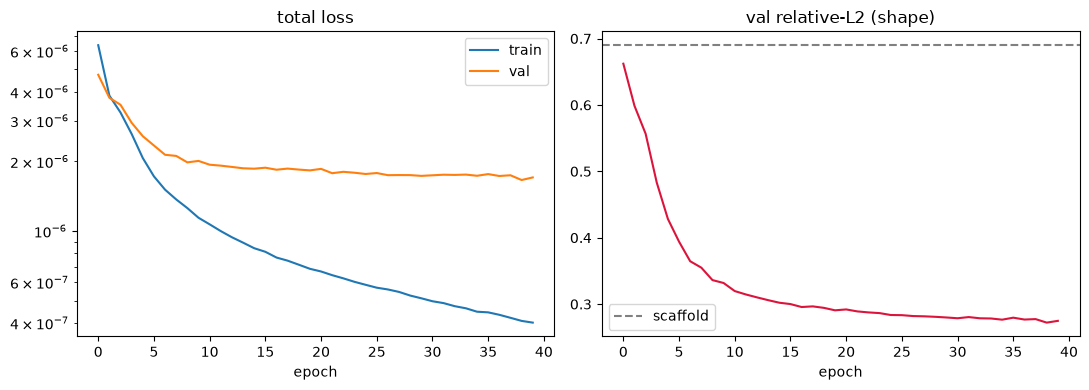

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(hist["train"], label="train"); ax[0].plot(hist["val"], label="val")
ax[0].set_yscale("log"); ax[0].set_xlabel("epoch"); ax[0].set_title("total loss"); ax[0].legend()
ax[1].plot(hist["val_l2"], color="crimson"); ax[1].axhline(0.69, ls="--", c="grey", label="scaffold")
ax[1].set_xlabel("epoch"); ax[1].set_title("val relative-L2 (shape)"); ax[1].legend()
fig.tight_layout()

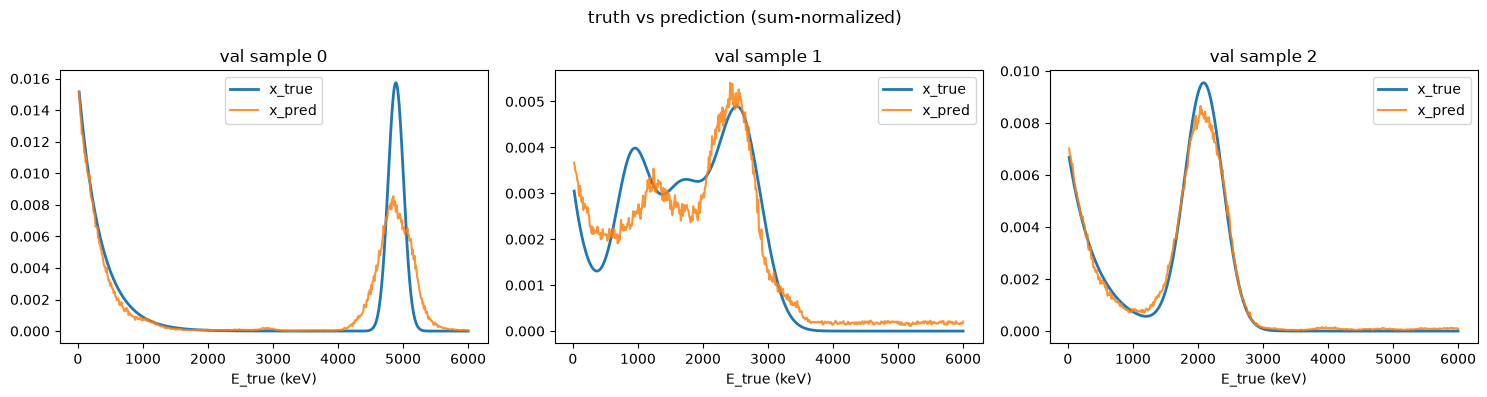

In [9]:
model.eval()
with torch.no_grad():
    xp = model(Yin_va[:3]).cpu().numpy()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, ax in enumerate(axes):
    ax.plot(rm.e_true_keV, X_va[k].numpy(), label="x_true", lw=2)
    ax.plot(rm.e_true_keV, xp[k], label="x_pred", lw=1.5, alpha=0.85)
    ax.set_xlabel("E_true (keV)"); ax.set_title(f"val sample {k}"); ax.legend()
fig.suptitle("truth vs prediction (sum-normalized)")
fig.tight_layout()

cross-sample std (mean over bins): 1.77e-03 | target per-bin scale ~ 1.67e-03


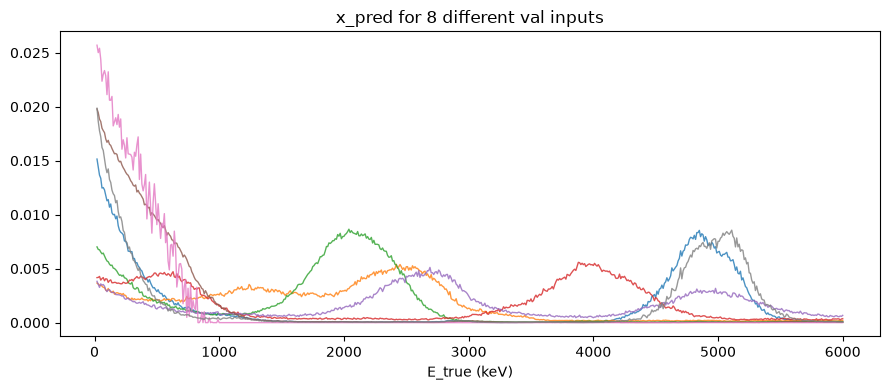

In [10]:
# mean-collapse check: overlay predictions for 8 different val inputs.
# If they lie on top of each other -> collapsed. If they differ -> input-responsive.
with torch.no_grad():
    P = model(Yin_va[:8]).cpu().numpy()
plt.figure(figsize=(9, 4))
for p in P:
    plt.plot(rm.e_true_keV, p, lw=1, alpha=0.8)
plt.xlabel("E_true (keV)"); plt.title("x_pred for 8 different val inputs")
plt.tight_layout()
print("cross-sample std (mean over bins):", f"{P.std(axis=0).mean():.2e}",
      "| target per-bin scale ~", f"{1/n_true:.2e}")

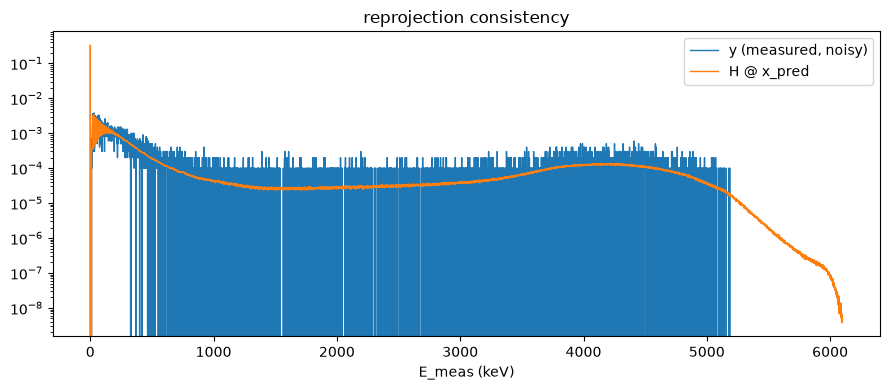

In [11]:
with torch.no_grad():
    xp0 = model(Yin_va[:1]).cpu().numpy()[0]
y_reproj = H_np @ xp0
y_reproj = y_reproj / y_reproj.sum()
plt.figure(figsize=(9, 4))
plt.plot(rm.e_meas_keV, Yn_va[0].cpu().numpy(), label="y (measured, noisy)", lw=1)
plt.plot(rm.e_meas_keV, y_reproj, label="H @ x_pred", lw=1)
plt.yscale("log"); plt.xlabel("E_meas (keV)"); plt.legend(); plt.title("reprojection consistency")
plt.tight_layout()

## 9. Save

In [12]:
out = REPO / "results"; out.mkdir(exist_ok=True)
ckpt = out / "mlp_baseline.pt"
torch.save({"state_dict": model.state_dict(), "cfg": CFG, "history": hist,
            "input_mu": mu, "input_sd": sd}, ckpt)
print("saved", ckpt, "(results/ is git-ignored)")

saved d:\projects\DAU_projects\ml-assisted-re-distribution\results\mlp_baseline.pt (results/ is git-ignored)


## Takeaways

- **MLP val relative-L2 ~0.28** vs scaffold **~0.69**, still improving, predictions vary
  across inputs -> the transformer's mean-collapse was **architecture + input scaling**,
  not a physics limit. `H_d` carries usable information.

### Next

1. **Fix the transformer**: feed it this same `log1p`+standardized input; replace the
   `interpolate -> Linear` head with learned upsampling (`ConvTranspose1d`) or an MLP head
   that can place sharp features.
2. **Push the MLP**: more samples (5-10k), more epochs, LR schedule, wider layers; add a
   peak-location / mean-energy term to the loss (paper metrics, not raw L2).
3. **Swap the prior** to the bi-Maxwellian family (`docs/considerations.md` 4.1) - physical
   and lower-variance.
4. **MLEM comparison**: run `src.mlem.run_mlem` on the same val set for a classical
   reference point.
5. Still need `H_e` / `H_tot` before any of this predicts the RE distribution.